In [1]:
from nns.memorygraphs.memorypool import FoveatedGraphMemory
mem = FoveatedGraphMemory(H=512, W=512)

from nns.cnns.features import RetinaModel, MultiScaleFeatureBank
retina = RetinaModel(edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.0)
msbank = MultiScaleFeatureBank(scales=[1.0, 2.0, 4.0], base_sigma=1.0)

In [2]:
from trail.pic_tools import *
from trail.matrix_tools import *

In [3]:
image_path = 'picture/OIP-C.jpg'  # [1, 3, 1280, 1920]
tensor, oringinal_image = image_to_tensor(image_path)

center_x = -1
center_y = -1
current_fix = (100, 100)

In [4]:
retina_out = retina(tensor, center_x = center_x, center_y = center_y)
cropped = retina_out[5]
msfb_out = msbank(cropped)

res = mem.run_one_step(retina_out, msfb_out, current_fix)
if res['move'] is not None:
    _, _, target = res['move']
    center_x = target[0]
    center_y = target[1]
    current_fix = (float(target[0]), float(target[1]))
    print(current_fix)
print(res['matched'], res['learned_nodes'])

(76.0, 116.0)
(92.0, 132.0)
(76.0, 116.0)
True [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 8, 9, 10, 11, 12, 8, 13, 10, 11, 12, 8, 13, 10, 11, 12, 14, 13, 10, 11, 12, 15, 16, 17, 18, 19, 20, 16, 17, 18, 19, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 8, 9, 10, 11, 12, 8, 13, 10, 11, 12, 20, 13, 10, 11, 12, 21, 13, 10, 11, 12, 14, 16, 17, 18, 19, 21, 16, 17, 18, 19, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 13, 10, 11, 12, 22, 13, 10, 11, 12, 14, 13, 10, 11, 12, 21, 16, 17, 18, 19, 15, 16, 17, 18, 19, 23, 24, 25, 26, 23, 24, 25, 26, 23, 24, 25, 26, 27, 28, 29, 30, 27, 28, 29, 30, 27, 28, 29, 30, 31, 27, 28, 29, 30, 31, 32, 33, 34, 35, 21, 36, 33, 34, 35, 21, 36, 33, 34, 35, 37, 36, 33, 34, 35, 22, 38, 39, 40, 41, 22, 38, 39, 40, 41, 23, 24, 25, 26, 23, 24, 25, 26, 23, 24, 25, 26, 27, 28, 29, 30, 27, 28, 29, 30, 27, 28, 29, 30, 31, 27, 28, 29, 3

In [5]:
print(res['mode'])

strengthen


In [6]:
from trail.foveated_visualization1 import visualize_step

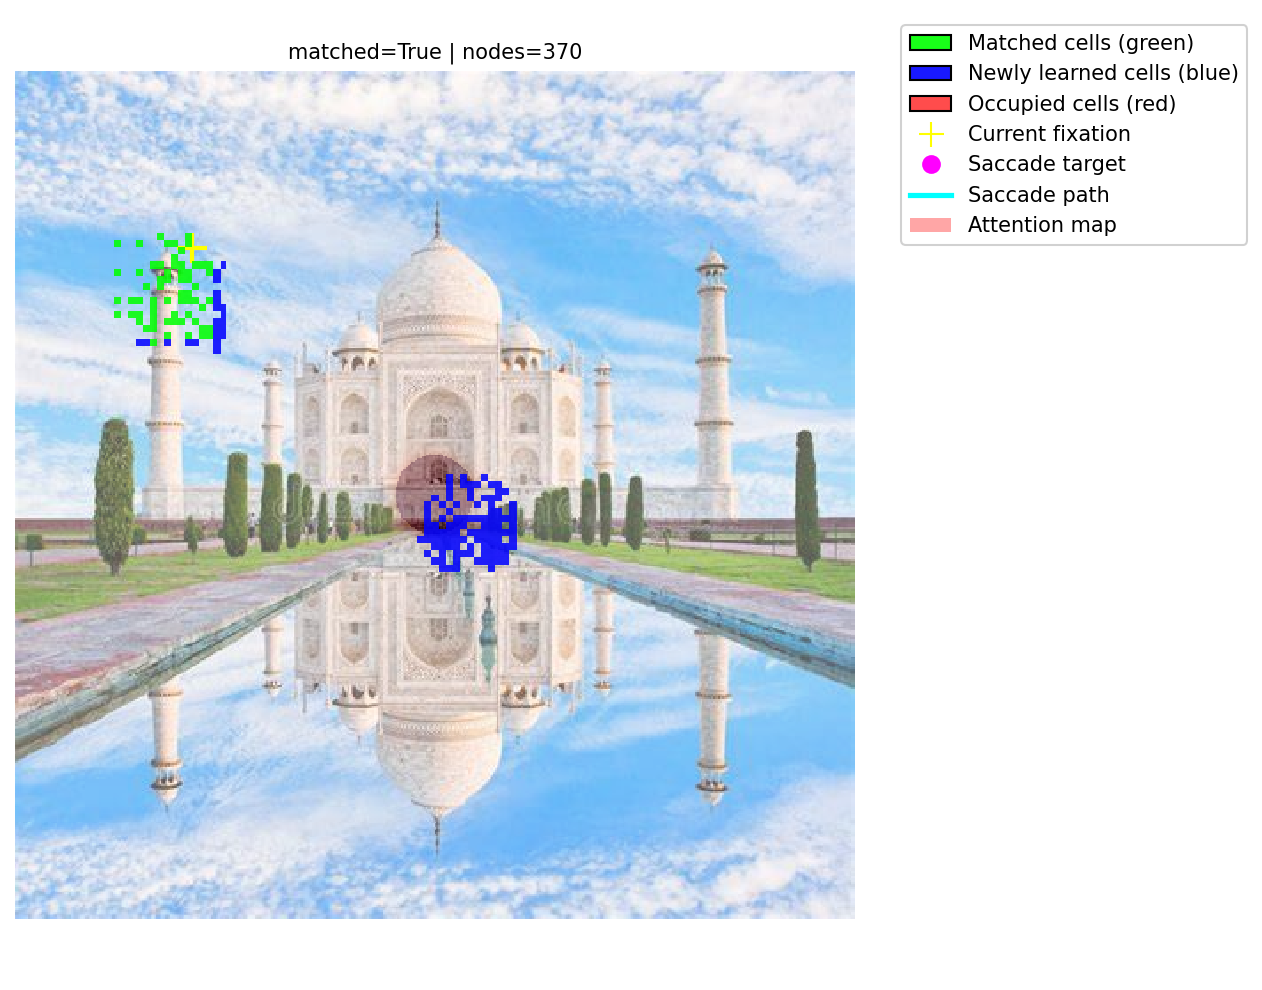

In [7]:

visualize_step(oringinal_image, mem, res, current_fix= current_fix)